# High-precision VQE convergence and ranking-stability check

Re-evaluates the leading circuits with 160 optimization steps and five restarts, compares low- and high-budget rankings, and saves convergence traces.

### Kaggle execution

1. Select a Python notebook and enable Internet for the first dependency installation if PennyLane is absent.
2. For publication runs leave `FAST_MODE = False`. Set it to `True` only for a short pipeline check.
3. Outputs are written to `/kaggle/working/qas_materials/`. Download them or create a Kaggle Dataset version for reuse.
4. The code uses exact state-vector simulation; a GPU accelerates neural training but not every PennyLane operation.

The notebook is self-contained and does not require cloning the GitHub repository.


In [1]:
# Install only when Kaggle's image does not already provide PennyLane.
import importlib.util, subprocess, sys
if importlib.util.find_spec("pennylane") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pennylane>=0.40,<0.44"])


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 762.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 33.6 MB/s eta 0:00:00


In [2]:
"""Shared, dependency-light core used verbatim in the Kaggle experiment notebooks.

The notebooks embed this file in a code cell, so they remain self-contained after
uploading to Kaggle.  The implementation deliberately avoids PyTorch Geometric.
"""

import os, json, math, random, time, hashlib
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml
from pennylane import numpy as pnp
from scipy.stats import kendalltau, spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_QUBITS = 6
NODE_FEAT_DIM = 24
EDGE_FEAT_DIM = 10
DEFAULT_SEEDS = [11, 23, 37, 51, 79]
DEFAULT_U_VALUES = list(range(9))
DATASET_VERSION = "2026-09-v3-pauli-factor-graph"
_PROBLEM_CACHE = {}
_GRAPH_LIST_CACHE = {}


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def output_dir():
    p = Path("/kaggle/working/qas_materials") if Path("/kaggle/working").exists() else Path("kaggle_outputs")
    p.mkdir(parents=True, exist_ok=True)
    return p


def locate_or_output(filename):
    """Prefer an attached Kaggle dataset, then the writable output directory."""
    local = output_dir() / filename
    if local.exists():
        return local
    root = Path("/kaggle/input")
    if root.exists():
        hits = list(root.rglob(filename))
        if hits:
            return hits[0]
    return local


def hubbard_problem(U, t=1.0):
    coeffs, ops = [], []
    for a, b in ((0, 1), (2, 3)):
        coeffs += [-t / 2, -t / 2]
        ops += [qml.X(a) @ qml.X(b), qml.Y(a) @ qml.Y(b)]
    for up, down in ((0, 2), (1, 3)):
        coeffs += [U / 4, -U / 4, -U / 4, U / 4]
        ops += [qml.Identity(0), qml.Z(up), qml.Z(down), qml.Z(up) @ qml.Z(down)]
    H = qml.Hamiltonian(coeffs, ops)
    return H, 4, np.array([1, 0, 0, 1], dtype=int)


def lih_problem(bond_length):
    mol = qml.qchem.Molecule(
        ["Li", "H"],
        pnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, float(bond_length)]], requires_grad=False),
        unit="angstrom", basis_name="sto-3g",
    )
    H, n = qml.qchem.molecular_hamiltonian(
        mol, method="dhf", mapping="jordan_wigner",
        active_electrons=2, active_orbitals=3,
    )
    return H, n, np.asarray(qml.qchem.hf_state(2, n), dtype=int)


def fixed_particle_ground_energy(H, n_qubits, particles=2):
    matrix = np.asarray(qml.matrix(H), dtype=complex)
    sector = [i for i in range(2 ** n_qubits) if i.bit_count() == particles]
    return float(np.linalg.eigvalsh(matrix[np.ix_(sector, sector)])[0])


def operator_pool(n_qubits):
    singles = [("S", (i, j)) for i in range(n_qubits) for j in range(i + 1, n_qubits)]
    doubles = []
    for wires in combinations(range(n_qubits), 4):
        a, b, c, d = wires
        doubles.extend([("D", (a, b, c, d)), ("D", (a, c, b, d))])
    return singles + doubles


def make_architectures(n_qubits, initial, n_arch=24, seed=11, forbidden=None):
    rng = np.random.default_rng(seed)
    occupied = np.flatnonzero(initial).tolist()
    virtual = np.flatnonzero(1 - np.asarray(initial)).tolist()
    pool = operator_pool(n_qubits)
    specs, seen = [], set() if forbidden is None else set(forbidden)
    for arch_id in range(n_arch):
        for _attempt in range(10000):
            depth = int(rng.integers(3, 9))
            gates = [pool[int(rng.integers(len(pool)))] for _ in range(depth)]
            if arch_id % 3 == 0 and len(occupied) >= 2 and len(virtual) >= 2:
                gates[0] = ("D", tuple(occupied[:2] + virtual[:2]))
            else:
                gates[0] = ("S", (occupied[arch_id % len(occupied)], virtual[arch_id % len(virtual)]))
            fingerprint = tuple((kind, tuple(wires)) for kind, wires in gates)
            if fingerprint not in seen:
                seen.add(fingerprint)
                break
        else:
            raise RuntimeError("Could not sample a unique architecture")
        specs.append({"arch_seed": int(seed), "arch_id": arch_id, "gates": gates})
    return specs


def gates_to_json(gates):
    return json.dumps([[kind, list(wires)] for kind, wires in gates], separators=(",", ":"))


def gates_from_json(value):
    raw = json.loads(value) if isinstance(value, str) else value
    return [(str(kind), tuple(int(w) for w in wires)) for kind, wires in raw]


def architecture_summary(gates):
    kinds = [g[0] for g in gates]
    return {
        "depth": len(gates),
        "n_single": kinds.count("S"),
        "n_double": kinds.count("D"),
        "n_parameters": len(gates),
    }


def evaluate_vqe(H, n_qubits, initial, gates, steps=60, restarts=2, lr=0.10, seed=0):
    """Noiseless, particle-conserving VQE label."""
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="autograd", diff_method="backprop")
    def energy(theta):
        qml.BasisState(initial, wires=range(n_qubits))
        for angle, (kind, wires) in zip(theta, gates):
            if kind == "S":
                qml.SingleExcitation(angle, wires=wires)
            else:
                qml.DoubleExcitation(angle, wires=wires)
        return qml.expval(H)

    rng = np.random.default_rng(seed)
    best, best_trace = np.inf, None
    for restart in range(restarts):
        theta = pnp.array(rng.normal(0.0, 0.08, len(gates)), requires_grad=True)
        opt = qml.AdamOptimizer(stepsize=lr)
        trace = []
        for step in range(steps):
            theta, old_energy = opt.step_and_cost(energy, theta)
            trace.append(float(old_energy))
        final = float(energy(theta))
        trace.append(final)
        if final < best:
            best, best_trace = final, trace
    return best, best_trace


def _dataset_config(fast=False):
    return dict(n_arch=8 if fast else 24, steps=12 if fast else 60,
                restarts=1 if fast else 2,
                seeds=DEFAULT_SEEDS[:2] if fast else DEFAULT_SEEDS,
                u_values=[0, 2, 4, 6, 8] if fast else DEFAULT_U_VALUES)


def ensure_hubbard_dataset(filename="hubbard_dense_multiseed.csv", fast=False, force=False):
    if fast and filename == "hubbard_dense_multiseed.csv":
        filename = "hubbard_dense_multiseed_fast.csv"
    cfg = _dataset_config(fast)
    path = locate_or_output(filename)
    expected = {(float(U), int(s), int(a)) for U in cfg["u_values"]
                for s in cfg["seeds"] for a in range(cfg["n_arch"])}
    rows, completed = [], set()
    if path.exists() and not force:
        old = pd.read_csv(path)
        if "dataset_version" in old and set(old.dataset_version) == {DATASET_VERSION}:
            rows = old.to_dict("records")
            completed = set(zip(old.parameter.astype(float), old.arch_seed.astype(int), old.arch_id.astype(int)))
            if expected.issubset(completed):
                print(f"Loaded {len(old):,} complete cached rows from {path}")
                return old
            print(f"Resuming partial cache with {len(old):,}/{len(expected):,} requested rows")
        else:
            print("Ignoring an incompatible cache created by an older experiment design")
    _, base_n, base_initial = hubbard_problem(0.0)
    pools, forbidden = {}, set()
    for arch_seed in cfg["seeds"]:
        pools[arch_seed] = make_architectures(base_n, base_initial, cfg["n_arch"], arch_seed, forbidden)
        forbidden.update(tuple((k, tuple(w)) for k, w in s["gates"]) for s in pools[arch_seed])
    start = time.time()
    for U in cfg["u_values"]:
        H, n, initial = hubbard_problem(U)
        exact = fixed_particle_ground_energy(H, n)
        analytic = 0.5 * (U - np.sqrt(U * U + 16.0))
        assert abs(exact - analytic) < 1e-10
        for arch_seed in cfg["seeds"]:
            specs = pools[arch_seed]
            for spec in specs:
                if (float(U), int(arch_seed), int(spec["arch_id"])) in completed:
                    continue
                # Common random numbers across U/t isolate Hamiltonian-parameter effects
                # from optimizer-initialization noise for a fixed architecture.
                run_seed = 100000 * arch_seed + 997 * spec["arch_id"]
                energy, _ = evaluate_vqe(H, n, initial, spec["gates"],
                                         cfg["steps"], cfg["restarts"], seed=run_seed)
                assert energy >= exact - 1e-7, "Variational bound violated beyond numerical tolerance"
                row = dict(dataset_version=DATASET_VERSION, family="Hubbard", parameter=float(U), arch_seed=arch_seed,
                           arch_id=spec["arch_id"], gates_json=gates_to_json(spec["gates"]),
                           energy=energy, exact=exact, gap=max(0.0, energy - exact),
                           label_steps=cfg["steps"], label_restarts=cfg["restarts"])
                row.update(architecture_summary(spec["gates"]))
                rows.append(row)
        pd.DataFrame(rows).to_csv(output_dir() / filename, index=False)
        print(f"U/t={U:g}: {len(rows):,} labels; elapsed {time.time()-start:.1f}s")
    frame = pd.DataFrame(rows)
    path = output_dir() / filename
    frame.to_csv(path, index=False)
    print(f"Saved {len(frame):,} rows to {path}")
    return frame


def ensure_lih_dataset(filename="lih_bond_multiseed.csv", fast=False, force=False):
    if fast and filename == "lih_bond_multiseed.csv":
        filename = "lih_bond_multiseed_fast.csv"
    path = locate_or_output(filename)
    bonds = [1.0, 1.4, 1.8, 2.4, 3.2] if fast else [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.2]
    seeds = DEFAULT_SEEDS[:2] if fast else DEFAULT_SEEDS
    n_arch, steps, restarts = (6, 12, 1) if fast else (18, 70, 2)
    expected = {(float(b), int(s), int(a)) for b in bonds for s in seeds for a in range(n_arch)}
    rows, completed = [], set()
    if path.exists() and not force:
        old = pd.read_csv(path)
        if "dataset_version" in old and set(old.dataset_version) == {DATASET_VERSION}:
            rows = old.to_dict("records")
            completed = set(zip(old.parameter.astype(float), old.arch_seed.astype(int), old.arch_id.astype(int)))
            if expected.issubset(completed):
                print(f"Loaded {len(old):,} complete cached rows from {path}")
                return old
            print(f"Resuming partial cache with {len(old):,}/{len(expected):,} requested rows")
        else:
            print("Ignoring an incompatible cache created by an older experiment design")
    base_initial = np.asarray(qml.qchem.hf_state(2, 6), dtype=int)
    pools, forbidden = {}, set()
    for arch_seed in seeds:
        pools[arch_seed] = make_architectures(6, base_initial, n_arch, arch_seed, forbidden)
        forbidden.update(tuple((k, tuple(w)) for k, w in s["gates"]) for s in pools[arch_seed])
    start = time.time()
    for bond in bonds:
        H, n, initial = lih_problem(bond)
        exact = fixed_particle_ground_energy(H, n)
        for arch_seed in seeds:
            for spec in pools[arch_seed]:
                if (float(bond), int(arch_seed), int(spec["arch_id"])) in completed:
                    continue
                # Reuse the same restart initializations along the bond scan.
                run_seed = 100000 * arch_seed + 997 * spec["arch_id"]
                energy, _ = evaluate_vqe(H, n, initial, spec["gates"], steps, restarts, seed=run_seed)
                assert energy >= exact - 1e-7, "Variational bound violated beyond numerical tolerance"
                row = dict(dataset_version=DATASET_VERSION, family="LiH", parameter=float(bond), arch_seed=arch_seed,
                           arch_id=spec["arch_id"], gates_json=gates_to_json(spec["gates"]),
                           energy=energy, exact=exact, gap=max(0.0, energy - exact),
                           label_steps=steps, label_restarts=restarts)
                row.update(architecture_summary(spec["gates"]))
                rows.append(row)
        pd.DataFrame(rows).to_csv(output_dir() / filename, index=False)
        print(f"R={bond:.1f} A: {len(rows):,} labels; elapsed {time.time()-start:.1f}s")
    frame = pd.DataFrame(rows)
    path = output_dir() / filename
    frame.to_csv(path, index=False)
    print(f"Saved {len(frame):,} rows to {path}")
    return frame


def pauli_support(op):
    factors = list(op.operands) if getattr(op, "operands", None) else [op]
    out = []
    for factor in factors:
        if factor.name in ("PauliX", "PauliY", "PauliZ"):
            out.append((int(list(factor.wires)[0]), factor.name[-1]))
    return out


def canonical_pauli_terms(H, n_qubits, tol=1e-12):
    """Aggregate duplicate Pauli words into a deterministic real coefficient map."""
    terms = {}
    coeffs, ops = H.terms()
    for coeff, op in zip(coeffs, ops):
        value = complex(coeff)
        assert abs(value.imag) < tol, "Expected a Hermitian Hamiltonian with real Pauli coefficients"
        word = ["I"] * n_qubits
        for q, axis in pauli_support(op):
            word[q] = axis
        key = tuple(word)
        terms[key] = terms.get(key, 0.0) + float(value.real)
    return {word: coeff for word, coeff in sorted(terms.items()) if abs(coeff) > tol}


def _set_edge(A, E, src, dst, relation, weight=1.0, axis=None,
              signed_coefficient=0.0, absolute_coefficient=0.0):
    A[src, dst] = float(weight)
    E[src, dst, :] = 0.0
    E[src, dst, relation] = 1.0
    if axis is not None:
        E[src, dst, 5 + {"X": 0, "Y": 1, "Z": 2}[axis]] = 1.0
    E[src, dst, 8] = signed_coefficient
    E[src, dst, 9] = absolute_coefficient


def _hamiltonian_factor_graph(H, n_qubits):
    """Lossless bipartite representation of an aggregated Pauli Hamiltonian.

    Node order is qubits, non-identity Pauli terms, global Hamiltonian node.
    Edge relations are self, circuit-circuit, term-qubit, global, circuit-qubit.
    """
    pauli = canonical_pauli_terms(H, n_qubits)
    identity_word = tuple("I" for _ in range(n_qubits))
    identity = pauli.get(identity_word, 0.0)
    nonidentity = [(word, coeff) for word, coeff in pauli.items() if word != identity_word]
    norm = max(1.0, sum(abs(coeff) for coeff in pauli.values()))
    n_nodes = n_qubits + len(nonidentity) + 1
    X = np.zeros((n_nodes, NODE_FEAT_DIM), dtype=np.float64)
    A = np.zeros((n_nodes, n_nodes), dtype=np.float64)
    E = np.zeros((n_nodes, n_nodes, EDGE_FEAT_DIM), dtype=np.float64)

    for q in range(n_qubits):
        X[q, 1] = 1.0
        X[q, 21] = q / max(1, MAX_QUBITS - 1)

    for k, (word, coeff) in enumerate(nonidentity):
        node = n_qubits + k
        axes = [axis for axis in word if axis != "I"]
        X[node, 2] = 1.0
        X[node, 14] = coeff / norm
        X[node, 15] = abs(coeff) / norm
        X[node, 16] = np.log1p(abs(coeff)) / np.log1p(norm)
        X[node, 17] = len(axes) / n_qubits
        for axis, feature in (("X", 18), ("Y", 19), ("Z", 20)):
            X[node, feature] = axes.count(axis) / max(1, len(axes))
        for q, axis in enumerate(word):
            if axis == "I":
                continue
            weight = max(abs(coeff) / norm, 1e-12)
            for src, dst in ((node, q), (q, node)):
                _set_edge(A, E, src, dst, relation=2, weight=weight, axis=axis,
                          signed_coefficient=coeff / norm,
                          absolute_coefficient=abs(coeff) / norm)

    global_node = n_nodes - 1
    X[global_node, 3] = 1.0
    X[global_node, 22] = np.log1p(norm)
    X[global_node, 23] = identity / norm
    for node in range(global_node):
        _set_edge(A, E, global_node, node, relation=3)
        _set_edge(A, E, node, global_node, relation=3)
    for node in range(n_nodes):
        _set_edge(A, E, node, node, relation=0)
    return X, A, E


def reconstruct_pauli_terms_from_factor_graph(X, A, E, n_qubits, tol=1e-12):
    """Reconstruct the Pauli dictionary from factor-graph arrays for unit testing."""
    global_nodes = np.flatnonzero(X[:, 3] > 0.5)
    assert len(global_nodes) == 1
    global_node = int(global_nodes[0])
    norm = float(np.expm1(X[global_node, 22]))
    identity_word = tuple("I" for _ in range(n_qubits))
    result = {}
    identity = float(X[global_node, 23] * norm)
    if abs(identity) > tol:
        result[identity_word] = identity
    for term_node in np.flatnonzero(X[:, 2] > 0.5):
        coeff = float(X[term_node, 14] * norm)
        word = ["I"] * n_qubits
        for q in range(n_qubits):
            if A[term_node, q] <= 0 or E[term_node, q, 2] < 0.5:
                continue
            word[q] = ("X", "Y", "Z")[int(np.argmax(E[term_node, q, 5:8]))]
        result[tuple(word)] = coeff
    return result


def validate_factor_graph_roundtrip(H, n_qubits, tol=1e-10):
    expected = canonical_pauli_terms(H, n_qubits)
    X, A, E = _hamiltonian_factor_graph(H, n_qubits)
    observed = reconstruct_pauli_terms_from_factor_graph(X, A, E, n_qubits)
    assert expected.keys() == observed.keys()
    error = max((abs(expected[k] - observed[k]) for k in expected), default=0.0)
    assert error < tol, f"Pauli factor-graph reconstruction error {error:g}"
    return error


def _hamiltonian_pairwise_graph(H, n_qubits):
    """Legacy lossy qubit-clique projection retained only as an ablation."""
    pauli = canonical_pauli_terms(H, n_qubits)
    identity_word = tuple("I" for _ in range(n_qubits))
    norm = max(1.0, sum(abs(coeff) for coeff in pauli.values()))
    global_node = n_qubits
    X = np.zeros((n_qubits + 1, NODE_FEAT_DIM), dtype=np.float64)
    A = np.zeros((n_qubits + 1, n_qubits + 1), dtype=np.float64)
    E = np.zeros((n_qubits + 1, n_qubits + 1, EDGE_FEAT_DIM), dtype=np.float64)
    pair_abs = np.zeros((n_qubits, n_qubits), dtype=float)
    pair_signed = np.zeros((n_qubits, n_qubits), dtype=float)
    for q in range(n_qubits):
        X[q, 1] = 1.0; X[q, 21] = q / max(1, MAX_QUBITS - 1)
    for word, coeff in pauli.items():
        support = [(q, axis) for q, axis in enumerate(word) if axis != "I"]
        for q, axis in support:
            X[q, 14] += coeff / norm
            X[q, 15] += abs(coeff) / norm
            X[q, 18 + {"X": 0, "Y": 1, "Z": 2}[axis]] += abs(coeff) / norm
        for (q, _), (r, _) in combinations(support, 2):
            pair_abs[q, r] += abs(coeff) / norm; pair_abs[r, q] += abs(coeff) / norm
            pair_signed[q, r] += coeff / norm; pair_signed[r, q] += coeff / norm
    for q in range(n_qubits):
        for r in range(n_qubits):
            if pair_abs[q, r] > 0:
                _set_edge(A, E, q, r, relation=2, weight=pair_abs[q, r],
                          signed_coefficient=pair_signed[q, r],
                          absolute_coefficient=pair_abs[q, r])
    X[global_node, 3] = 1.0
    X[global_node, 22] = np.log1p(norm)
    X[global_node, 23] = pauli.get(identity_word, 0.0) / norm
    for q in range(n_qubits):
        _set_edge(A, E, global_node, q, relation=3)
        _set_edge(A, E, q, global_node, relation=3)
    for node in range(n_qubits + 1):
        _set_edge(A, E, node, node, relation=0)
    return X, A, E


def _circuit_node_features(gates, n_qubits):
    m = len(gates)
    X = np.zeros((m, NODE_FEAT_DIM), dtype=np.float64)
    A = np.zeros((m, m), dtype=np.float64)
    E = np.zeros((m, m, EDGE_FEAT_DIM), dtype=np.float64)
    for i, (kind, wires) in enumerate(gates):
        X[i, 0] = 1.0
        X[i, 4 if kind == "S" else 5] = 1.0
        X[i, 6] = i / max(1, m - 1)
        X[i, 7] = m / 10.0
        for w in wires:
            X[i, 8 + w] = 1.0
        if i:
            _set_edge(A, E, i, i - 1, relation=1)
            _set_edge(A, E, i - 1, i, relation=1)
    for i in range(m):
        wi = set(gates[i][1])
        for j in range(i):
            if wi.intersection(gates[j][1]):
                _set_edge(A, E, i, j, relation=1)
                _set_edge(A, E, j, i, relation=1)
    for node in range(m):
        _set_edge(A, E, node, node, relation=0)
    return X, A, E


def _edge_data(A, E):
    src, dst = np.nonzero(A > 0)
    edge = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
    weight = torch.tensor(A[src, dst], dtype=torch.float32)
    edge_attr = torch.tensor(E[src, dst], dtype=torch.float32)
    return edge, weight, edge_attr


def graph_from_row(row, mode="joint"):
    gates = gates_from_json(row["gates_json"])
    key = (str(row["family"]), float(row["parameter"]))
    if key not in _PROBLEM_CACHE and row["family"] == "Hubbard":
        _PROBLEM_CACHE[key] = hubbard_problem(float(row["parameter"]))
    elif key not in _PROBLEM_CACHE and row["family"] == "LiH":
        _PROBLEM_CACHE[key] = lih_problem(float(row["parameter"]))
    if key in _PROBLEM_CACHE:
        H, n, _ = _PROBLEM_CACHE[key]
    else:
        raise ValueError(row["family"])
    C, Ac, Ec = _circuit_node_features(gates, n)
    use_pairwise = mode in ("hamiltonian_pairwise", "joint_pairwise")
    Q, Ah, Eh = (_hamiltonian_pairwise_graph(H, n) if use_pairwise
                 else _hamiltonian_factor_graph(H, n))
    if mode == "circuit":
        X, A, E = C, Ac, Ec
    elif mode in ("hamiltonian", "hamiltonian_pairwise"):
        X, A, E = Q, Ah, Eh
    elif mode in ("joint", "joint_pairwise"):
        X = np.vstack([C, Q])
        A = np.zeros((len(X), len(X)), dtype=np.float64)
        E = np.zeros((len(X), len(X), EDGE_FEAT_DIM), dtype=np.float64)
        A[:len(C), :len(C)] = Ac
        E[:len(C), :len(C)] = Ec
        A[len(C):, len(C):] = Ah
        E[len(C):, len(C):] = Eh
        for i, (_, wires) in enumerate(gates):
            for w in wires:
                _set_edge(A, E, i, len(C) + w, relation=4)
                _set_edge(A, E, len(C) + w, i, relation=4)
    else:
        raise ValueError(mode)
    edge, weight, edge_attr = _edge_data(A, E)
    return torch.tensor(X, dtype=torch.float32), edge, weight, edge_attr


def build_graph_list(frame, mode):
    signature_columns = ["family", "parameter", "arch_seed", "arch_id", "gates_json"]
    hashed = pd.util.hash_pandas_object(frame[signature_columns], index=False).to_numpy().tobytes()
    key = (hashlib.sha1(hashed).hexdigest(), mode)
    if key not in _GRAPH_LIST_CACHE:
        _GRAPH_LIST_CACHE[key] = [(*graph_from_row(row, mode), float(row["gap"]))
                                  for _, row in frame.iterrows()]
    return _GRAPH_LIST_CACHE[key]


def collate_graphs(items, indices, device=DEVICE):
    xs, edges, weights, attrs, batches, ys, offset = [], [], [], [], [], [], 0
    for b, idx in enumerate(indices):
        x, edge, weight, edge_attr, y = items[int(idx)]
        xs.append(x); edges.append(edge + offset); weights.append(weight); attrs.append(edge_attr)
        batches.append(torch.full((len(x),), b, dtype=torch.long)); ys.append(y)
        offset += len(x)
    return (torch.cat(xs).to(device), torch.cat(edges, 1).to(device), torch.cat(weights).to(device),
            torch.cat(attrs).to(device),
            torch.cat(batches).to(device), torch.tensor(ys, dtype=torch.float32, device=device))


class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, concat=True, dropout=0.10,
                 edge_dim=EDGE_FEAT_DIM):
        super().__init__()
        self.heads, self.out_dim, self.concat = heads, out_dim, concat
        self.W = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.a_src = nn.Parameter(torch.empty(heads, out_dim))
        self.a_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.a_edge = nn.Parameter(torch.empty(heads, out_dim))
        self.edge_projection = nn.Linear(edge_dim, heads * out_dim, bias=False)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a_src); nn.init.xavier_uniform_(self.a_dst)
        nn.init.xavier_uniform_(self.a_edge); nn.init.xavier_uniform_(self.edge_projection.weight)

    def forward(self, x, edge_index, edge_weight, edge_attr):
        n, hds, dim = x.size(0), self.heads, self.out_dim
        h = self.W(x).view(n, hds, dim)
        src, dst = edge_index
        edge_embedding = self.edge_projection(edge_attr).view(-1, hds, dim)
        logits = F.leaky_relu((h[src] * self.a_src).sum(-1) +
                              (h[dst] * self.a_dst).sum(-1) +
                              (edge_embedding * self.a_edge).sum(-1), 0.2)
        # Positive interaction strength is an attention prior; it is no longer
        # discarded when the weighted Hamiltonian adjacency becomes edge_index.
        logits = logits + torch.log(edge_weight.clamp_min(1e-8)).unsqueeze(-1)
        # Stable per-destination softmax. Graphs are tiny, so the explicit loop is reliable.
        alpha = torch.zeros_like(logits)
        for node in torch.unique(dst):
            mask = dst == node
            alpha[mask] = torch.softmax(logits[mask], dim=0)
        alpha = self.dropout(alpha)
        out = torch.zeros(n, hds, dim, device=x.device)
        out.index_add_(0, dst, (h[src] + edge_embedding) * alpha.unsqueeze(-1))
        return out.reshape(n, hds * dim) if self.concat else out.mean(1)


def graph_pool(h, batch):
    pooled = []
    for b in range(int(batch.max().item()) + 1):
        z = h[batch == b]
        pooled.append(torch.cat([z.mean(0), z.max(0).values]))
    return torch.stack(pooled)


class GraphEncoder(nn.Module):
    def __init__(self, in_dim=NODE_FEAT_DIM, hidden=24, heads=3):
        super().__init__()
        self.g1 = GATLayer(in_dim, hidden, heads=heads, concat=True)
        self.g2 = GATLayer(hidden * heads, hidden, heads=heads, concat=False)

    def forward(self, x, edge, edge_weight, edge_attr, batch):
        h = F.elu(self.g1(x, edge, edge_weight, edge_attr))
        h = F.elu(self.g2(h, edge, edge_weight, edge_attr))
        return graph_pool(h, batch)


class KANLinear(nn.Module):
    def __init__(self, in_dim, out_dim, grid_size=5, spline_order=3):
        super().__init__()
        self.spline_order = spline_order
        step = 2.0 / grid_size
        grid = torch.linspace(-1 - spline_order * step, 1 + spline_order * step,
                              grid_size + 2 * spline_order + 1)
        self.register_buffer("grid", grid)
        self.spline_weight = nn.Parameter(torch.randn(out_dim, in_dim, grid_size + spline_order) * 0.05)
        self.residual_weight = nn.Parameter(torch.empty(out_dim, in_dim))
        nn.init.kaiming_uniform_(self.residual_weight, a=math.sqrt(5))

    def _basis(self, x):
        x = x.unsqueeze(-1); grid = self.grid
        basis = ((x >= grid[:-1]) & (x < grid[1:])).float()
        for k in range(1, self.spline_order + 1):
            dl = (grid[k:-1] - grid[:-(k + 1)]).clamp_min(1e-8)
            dr = (grid[k + 1:] - grid[1:-k]).clamp_min(1e-8)
            basis = (x - grid[:-(k + 1)]) / dl * basis[..., :-1] + \
                    (grid[k + 1:] - x) / dr * basis[..., 1:]
        return basis

    def forward(self, x):
        basis = self._basis(x.clamp(-0.99999, 0.99999))
        return torch.einsum("bin,oin->bo", basis, self.spline_weight) + F.silu(x) @ self.residual_weight.t()


class GraphPredictor(nn.Module):
    def __init__(self, head="mlp", hidden=24, heads=3):
        super().__init__()
        self.encoder = GraphEncoder(hidden=hidden, heads=heads)
        if head == "mlp":
            self.head = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.ELU(), nn.Linear(hidden, 1))
        elif head == "kan":
            self.head = nn.Sequential(KANLinear(2 * hidden, hidden), nn.ELU(), KANLinear(hidden, 1))
        else:
            raise ValueError(head)

    def forward(self, x, edge, edge_weight, edge_attr, batch):
        return self.head(self.encoder(x, edge, edge_weight, edge_attr, batch)).squeeze(-1)


def _predict(model, graphs, indices, batch_size=64):
    model.eval(); out = []
    with torch.no_grad():
        for start in range(0, len(indices), batch_size):
            x, e, w, a, b, _ = collate_graphs(graphs, indices[start:start + batch_size])
            out.extend(model(x, e, w, a, b).cpu().numpy().tolist())
    return np.asarray(out)


def macro_ranking_metrics(frame, indices, prediction):
    """Average within-Hamiltonian ranking metrics; never pool different H values."""
    view = frame.iloc[np.asarray(indices, dtype=int)][["family", "parameter", "gap"]].copy()
    view["prediction"] = np.asarray(prediction)
    rows = []
    for (family, parameter), group in view.groupby(["family", "parameter"], dropna=False):
        tau = kendalltau(group["gap"], group["prediction"]).statistic
        rho = spearmanr(group["gap"], group["prediction"]).statistic
        rows.append((family, parameter, len(group), tau, rho))
    valid_tau = [r[3] for r in rows if not np.isnan(r[3])]
    valid_rho = [r[4] for r in rows if not np.isnan(r[4])]
    return {
        "test_tau": float(np.mean(valid_tau)) if valid_tau else np.nan,
        "test_spearman": float(np.mean(valid_rho)) if valid_rho else np.nan,
        "n_hamiltonians": len(rows),
        "n_defined_tau": len(valid_tau),
    }


def within_hamiltonian_training_targets(frame, train_idx):
    """Standardize observable VQE energies separately per training Hamiltonian.

    Exact ground energies and test/validation labels are deliberately excluded.
    """
    target = np.zeros(len(frame), dtype=float)
    train_positions = np.asarray(train_idx, dtype=int)
    train_view = frame.iloc[train_positions][["family", "parameter", "energy"]].copy()
    train_view["_position"] = train_positions
    for _, group in train_view.groupby(["family", "parameter"], dropna=False):
        idx = group["_position"].to_numpy(dtype=int)
        energy = group["energy"].to_numpy(float)
        scale = energy.std() + 1e-8
        target[idx] = (energy - energy.mean()) / scale
    return target


def train_graph_model(frame, mode, train_idx, val_idx, test_idx, head="mlp", seed=0,
                      epochs=180, batch_size=48, patience=25):
    seed_everything(seed)
    graphs = build_graph_list(frame, mode)
    train_idx, val_idx, test_idx = map(lambda x: np.asarray(x, dtype=int), (train_idx, val_idx, test_idx))
    target = within_hamiltonian_training_targets(frame, train_idx)
    for i, graph in enumerate(graphs):
        graph_list = list(graph); graph_list[4] = target[i]; graphs[i] = tuple(graph_list)
    model = GraphPredictor(head=head).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    best_state, best_tau, stale = None, -np.inf, 0
    rng = np.random.default_rng(seed)
    for epoch in range(epochs):
        model.train(); order = rng.permutation(train_idx)
        for start in range(0, len(order), batch_size):
            batch_ids = order[start:start + batch_size]
            x, e, w, a, b, y = collate_graphs(graphs, batch_ids)
            pred = model(x, e, w, a, b)
            mse = F.mse_loss(pred, y)
            # Ranking is meaningful only among circuits evaluated on the same H.
            batch_meta = frame.iloc[batch_ids][["family", "parameter"]]
            families = batch_meta["family"].astype(str).to_numpy()
            parameters = batch_meta["parameter"].to_numpy(float)
            pairs = []
            for family, parameter in sorted(set(zip(families, parameters)), key=lambda z: (z[0], z[1])):
                loc = np.flatnonzero((families == family) & (parameters == parameter))
                pairs.extend(combinations(loc.tolist(), 2))
            if pairs:
                if len(pairs) > 256:
                    chosen = rng.choice(len(pairs), size=256, replace=False)
                    pairs = [pairs[i] for i in chosen]
                a = torch.tensor([p[0] for p in pairs], dtype=torch.long, device=DEVICE)
                c = torch.tensor([p[1] for p in pairs], dtype=torch.long, device=DEVICE)
                sign = torch.sign(y[a] - y[c])
                rank = F.relu(0.10 - sign * (pred[a] - pred[c]))[sign != 0].mean()
                if torch.isnan(rank): rank = torch.tensor(0.0, device=DEVICE)
            else:
                rank = torch.tensor(0.0, device=DEVICE)
            opt.zero_grad(); (mse + rank).backward(); opt.step()
        val_pred = _predict(model, graphs, val_idx)
        tau = macro_ranking_metrics(frame, val_idx, val_pred)["test_tau"]
        tau = -np.inf if np.isnan(tau) else float(tau)
        if best_state is None or tau > best_tau + 1e-4:
            best_tau, stale = tau, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
        if stale >= patience:
            break
    model.load_state_dict(best_state)
    prediction = _predict(model, graphs, test_idx)
    info = {"val_tau": np.nan if best_tau == -np.inf else best_tau, "epochs": epoch + 1}
    info.update(macro_ranking_metrics(frame, test_idx, prediction))
    return model, prediction, info


def scalar_ridge_baseline(frame, train_idx, val_idx, test_idx):
    cols = ["depth", "n_parameters", "n_single", "n_double"]
    X = frame[cols].to_numpy(float)
    y = within_hamiltonian_training_targets(frame, train_idx)
    scaler = StandardScaler().fit(X[train_idx])
    best = None
    for alpha in 10.0 ** np.arange(-4, 5):
        model = Ridge(alpha=alpha).fit(scaler.transform(X[train_idx]), y[train_idx])
        pred = model.predict(scaler.transform(X[val_idx]))
        tau = macro_ranking_metrics(frame, val_idx, pred)["test_tau"]
        score = -np.inf if np.isnan(tau) else tau
        if best is None or score > best[0]: best = (score, alpha, model)
    pred = best[2].predict(scaler.transform(X[test_idx]))
    info = {"val_tau": best[0], "alpha": best[1]}
    info.update(macro_ranking_metrics(frame, test_idx, pred))
    return pred, info


def split_mask(frame, arch_train, arch_val, arch_test, param_train, param_val, param_test):
    seeds = frame["arch_seed"].to_numpy(); params = frame["parameter"].to_numpy()
    return {
        "train": np.flatnonzero(np.isin(seeds, arch_train) & np.isin(params, param_train)),
        "val": np.flatnonzero(np.isin(seeds, arch_val) & np.isin(params, param_val)),
        "test": np.flatnonzero(np.isin(seeds, arch_test) & np.isin(params, param_test)),
    }


def assert_architecture_disjoint(frame, left_idx, right_idx):
    left = set(frame.iloc[np.asarray(left_idx, dtype=int)]["gates_json"])
    right = set(frame.iloc[np.asarray(right_idx, dtype=int)]["gates_json"])
    overlap = left.intersection(right)
    assert not overlap, f"Exact circuit duplicates cross the architecture split: {len(overlap)}"


def bootstrap_mean_ci(values, n_boot=10000, seed=2026):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    means = np.mean(rng.choice(values, size=(n_boot, len(values)), replace=True), axis=1)
    return float(values.mean()), float(values.std(ddof=1)), tuple(np.quantile(means, [0.025, 0.975]))


print("Core ready | PennyLane", qml.__version__, "| PyTorch", torch.__version__, "| device", DEVICE)


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Core ready | PennyLane 0.43.3 | PyTorch 2.10.0+cu128 | device cuda


In [3]:
# False = requested publication configuration; True = quick functional check
FAST_MODE = False
seed_everything(20260906)
print("Output directory:", output_dir())


Output directory: /kaggle/working/qas_materials


In [4]:
df = ensure_hubbard_dataset(fast=FAST_MODE)


Loaded 1,080 complete cached rows from /kaggle/input/datasets/deepsemantics/qas-dataset/qas_materials/hubbard_dense_multiseed.csv


In [5]:
check_u = sorted(set(df.parameter.unique()) & set([0,4,8]))
top_k = 2 if FAST_MODE else 5
selected = (df[df.parameter.isin(check_u)].sort_values("gap")
            .groupby(["arch_seed","parameter"],as_index=False).head(top_k).copy())
print("High-precision evaluations:",len(selected))
display(selected[["parameter","arch_seed","arch_id","gap"]].head(10))


High-precision evaluations: 75


,parameter,arch_seed,arch_id,gap
546,4.0,37,18,0.000002
83,0.0,51,11,0.000011
30,0.0,23,6,0.000012
27,0.0,23,3,0.000033
108,0.0,79,12,0.000039
112,0.0,79,16,0.000047
975,8.0,11,15,0.000047
1,0.0,11,1,0.000060
1072,8.0,79,16,0.000069
90,0.0,51,18,0.000075


In [6]:
hp_rows=[]; example_trace=None; started=time.time()
hp_steps, hp_restarts = (30,2) if FAST_MODE else (160,5)
for count, (_, row) in enumerate(selected.iterrows(),1):
    H,n,initial=hubbard_problem(float(row.parameter))
    energy,trace=evaluate_vqe(H,n,initial,gates_from_json(row.gates_json),
                              steps=hp_steps,restarts=hp_restarts,
                              seed=900000+int(row.arch_seed)*100+int(row.arch_id))
    hp_rows.append({**row.to_dict(),"high_energy":energy,
                    "high_gap":max(0.,energy-float(row.exact)),
                    "high_steps":hp_steps,"high_restarts":hp_restarts})
    if example_trace is None: example_trace=trace
    if count%10==0 or count==len(selected): print(count,"/",len(selected),"elapsed",round(time.time()-started,1),"s")
hp=pd.DataFrame(hp_rows)
hp.to_csv(output_dir()/"vqe_high_precision_check.csv",index=False)


10 / 75 elapsed 165.2 s
20 / 75 elapsed 313.7 s
30 / 75 elapsed 474.2 s
40 / 75 elapsed 636.4 s
50 / 75 elapsed 805.0 s
60 / 75 elapsed 959.4 s
70 / 75 elapsed 1126.5 s
75 / 75 elapsed 1202.5 s


In [7]:
stability=[]
for key,g in hp.groupby(["arch_seed","parameter"]):
    stability.append({"arch_seed":key[0],"parameter":key[1],"n":len(g),
                      "Kendall_tau":kendalltau(g.gap,g.high_gap).statistic,
                      "top1_unchanged":int(g.sort_values("gap").iloc[0].arch_id==g.sort_values("high_gap").iloc[0].arch_id),
                      "median_gap_change":float(np.median(g.high_gap-g.gap))})
stability=pd.DataFrame(stability)
display(stability)
print("Mean ranking stability:",stability.Kendall_tau.mean())
print("Top-1 agreement:",stability.top1_unchanged.mean())
stability.to_csv(output_dir()/"vqe_ranking_stability.csv",index=False)


,arch_seed,parameter,n,Kendall_tau,top1_unchanged,median_gap_change
0,11,0.0,5,-0.2,0,-0.000405
1,11,4.0,5,-0.2,1,-0.000679
2,11,8.0,5,0.4,0,-0.000351
3,23,0.0,5,0.2,0,-0.000199
4,23,4.0,5,0.0,0,-0.000581
5,23,8.0,5,0.8,1,-0.000983
6,37,0.0,5,0.4,0,-0.000566
7,37,4.0,5,0.8,1,-0.005231
8,37,8.0,5,1.0,1,-0.002813
9,51,0.0,5,-0.4,0,-0.000207


Mean ranking stability: 0.21333333333333332
Top-1 agreement: 0.4


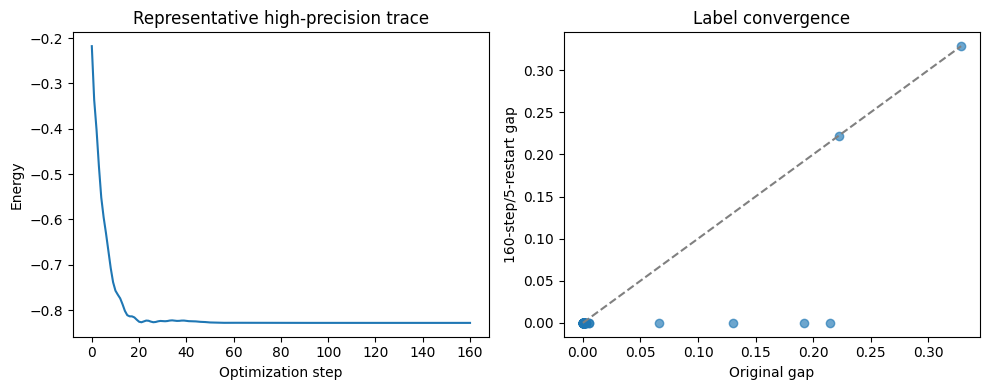

In [8]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(example_trace); axes[0].set(xlabel="Optimization step",ylabel="Energy",title="Representative high-precision trace")
axes[1].scatter(hp.gap,hp.high_gap,alpha=.65); lim=max(hp.gap.max(),hp.high_gap.max()); axes[1].plot([0,lim],[0,lim],'--',color='gray')
axes[1].set(xlabel="Original gap",ylabel="160-step/5-restart gap",title="Label convergence")
plt.tight_layout();plt.show()
